# 16 — TNG vs SAGA/ELVES satellite anisotropy ($M_{*,\rm sat}>10^8\,M_\odot$)

Two-panel comparison of the **azimuthal anisotropy** $P(\theta)$ of satellites
($\theta\in[0,90]$, $0^\circ$ = host major axis), combining:

* **Left panel** — the simulation, from `06_tng_anisotropy_z0_z0p05_logM8.ipynb`:
  a single TNG box (TNG100 or TNG50) at **z = 0** and **z = 0.05**.
* **Right panel** — the observations, from `07_saga_elves_anisotropy_variations.ipynb`:
  **SAGA Gold+Silver** and the **ELVES** sample, with **no inclination cut** and
  **no early-type cut** (all ELVES hosts kept, all satellites kept).

The figure is produced twice:
1. TNG100 (z=0, z=0.05) vs SAGA/ELVES,
2. TNG50 (z=0, z=0.05) vs SAGA/ELVES.

Each dataset's histogram $P(\theta)$ is overlaid with the MCMC posterior-median model
$p(\theta)=\tfrac{1}{90}(1+A\cos2\theta)$ (unbinned $A$ fit, same as notebook 07).
A flat line ($A=0$) is isotropic; a rise toward $\theta=0$ is major-axis alignment.

A third figure adds the **satellite quench fraction** $f_q(\theta)=a+b\cos2\theta$ with its MCMC
sinusoid fit (same model as notebooks 03/06/07), for **TNG100** (z=0, z=0.05) and SAGA/ELVES.

Requires internet (SIMBAD) for the ELVES host position angles, exactly like `07`.
TNG masses are physical $M_\odot$ (see `../docs/conventions.md`).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad

warnings.filterwarnings("ignore")
%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# --- configuration -----------------------------------------------------------
DATA_ROOT = "../data"
SAGA_DIR  = f"{DATA_ROOT}/saga"
ELVES_DIR = f"{DATA_ROOT}/elves"

LOGCUT   = 8                                            # M*_sat > 1e8
CAT_NAME = f"tng100_satellites_logM{LOGCUT:.2f}.csv"    # same filename in every TNG subdir

# 18 angle bins over [0, 90]
N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])

# panel colors
SAGA_C, ELVES_C = "#1f77b4", "#d62728"                  # right panel (obs)
TNG_C = "#1f77b4"                                        # left panel (sim); z distinguished by ls

## Helpers

`norm_hist` gives the normalized $P(\theta)$; `fit_anisotropy` is the unbinned MCMC fit of
$p(\theta)\propto1+A\cos2\theta$ from notebook 07; `model_curve` evaluates the posterior-median
model; `map_to_0_90` / `calc_r200` mirror notebook 07 for the SAGA/ELVES geometry.
`bootstrap_fq` / `fit_fq_sinusoid` / `fq_band` are the quench-fraction sinusoid pieces
$f_q(\theta)=a+b\cos2\theta$ (identical to notebooks 03/06/07).

In [2]:
def norm_hist(theta):
    c, _ = np.histogram(theta, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def model_curve(A):
    x = np.linspace(0, 90, 200)
    return x, (1.0 / 90.0) * (1.0 + A * np.cos(2 * np.radians(x)))

def fit_anisotropy(theta_deg, n_walkers=16, n_steps=4000, burn=1000, seed=0):
    '''MCMC of p(theta) ~ 1 + A cos(2 theta). Returns dict with A median/std/percentiles.'''
    th = np.radians(np.asarray(theta_deg, dtype=float))
    c2 = np.cos(2 * th)
    n = len(th)
    if n < 5:
        return dict(n=n, A=np.nan, Aerr=np.nan, lo=np.nan, hi=np.nan)

    def log_prob(p):
        A = p[0]
        if not (-0.999 < A < 0.999):
            return -np.inf
        v = 1.0 + A * c2
        if np.any(v <= 0):
            return -np.inf
        return np.sum(np.log(v))

    rng = np.random.default_rng(seed)
    p0 = rng.uniform(-0.1, 0.1, size=(n_walkers, 1))
    sampler = emcee.EnsembleSampler(n_walkers, 1, log_prob)
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)[:, 0]
    lo, med, hi = np.percentile(chain, [16, 50, 84])
    return dict(n=n, A=med, Aerr=chain.std(), lo=lo, hi=hi)

def map_to_0_90(angles):
    '''Fold angles (deg) into [0, 90] using the ellipse four-fold symmetry.'''
    a = np.mod(np.asarray(angles, dtype=float), 360.0)
    return np.where(a <= 90, a,
           np.where(a <= 180, 180 - a,
           np.where(a <= 270, a - 180, 360 - a)))

def calc_r200(mhalo_msun):
    '''R_200c [kpc] for a halo of mass mhalo_msun [M_sun]. (from J. Zhu)'''
    import astropy.constants as const
    from astropy.cosmology import Planck18 as cosmo
    mhalo = np.asarray(mhalo_msun) * u.Msun
    rho_c = cosmo.critical_density0
    r200c = ((3 * mhalo / (4 * np.pi * 200.0 * rho_c)) ** (1 / 3)).to(u.kpc)
    return r200c.value

# ---- quench fraction f_q = a + b cos(2 theta) (as in notebooks 03/06/07) -----
def bootstrap_fq(angle, quenched, N=5000, seed=0):
    '''Binned-mean quench fraction per angle bin, with bootstrap mean and 1-sigma error.'''
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def _fq_log_prob(theta, x, y, sigma):
    a, b, f = theta
    if not (0 < a < 1 and -1 < b < 1 and -10 < f < 2):
        return -np.inf
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def fit_fq_sinusoid(mean, std, n_walkers=20, n_steps=6000, burn=1000, seed=0):
    '''MCMC fit of f_q = a + b cos(2 theta); returns (params_mean, params_std).'''
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    if ok.sum() < 4:
        return np.array([np.nan] * 3), np.array([np.nan] * 3)
    p0 = np.array([0.5, 0.0, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, _fq_log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

def fq_band(p, e, n_mc=5000, seed=0):
    '''Posterior median + 16/84th-percentile band of f_q = a + b cos(2 theta) over [0, 90].'''
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 300)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    yy = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    return np.degrees(x), a.mean() + b.mean() * np.cos(2 * x), np.percentile(yy, 16, 0), np.percentile(yy, 84, 0)

## Load the TNG catalogs (TNG100 & TNG50, z=0 and z=0.05)

Same per-satellite catalogs as notebook 06; we keep the `alpha` ($0$-$90^\circ$) angle and
re-apply the $M_*>10^8\,M_\odot$ cut explicitly.

In [3]:
tng_alpha, tng_quench = {}, {}   # (sim, zsub) -> alpha / quenched arrays
for sim in ("tng100", "tng50"):
    for zsub in ("z0", "z0p05"):
        path = os.path.join(DATA_ROOT, sim, zsub, CAT_NAME)
        df = pd.read_csv(path)
        df = df[df["mstar_phys"] > LOGCUT]
        tng_alpha[(sim, zsub)]  = df["alpha"].to_numpy()
        tng_quench[(sim, zsub)] = df["quenched"].to_numpy(dtype=float)
        print(f"{sim:6s} {zsub:5s}: {len(df):5d} sats   f_q = {df['quenched'].mean():.3f}   ({path})")

tng100 z0   :  2165 sats   f_q = 0.364   (../data/tng100/z0/tng100_satellites_logM8.00.csv)
tng100 z0p05:  2218 sats   f_q = 0.342   (../data/tng100/z0p05/tng100_satellites_logM8.00.csv)
tng50  z0   :   448 sats   f_q = 0.382   (../data/tng50/z0/tng100_satellites_logM8.00.csv)
tng50  z0p05:   426 sats   f_q = 0.394   (../data/tng50/z0p05/tng100_satellites_logM8.00.csv)


## SAGA: Gold + Silver, within $R_{200}$, no inclination cut

Join the DR3 host (Table C1) and satellite (Table C3) tables and compute each satellite's
projected angle from its host major axis (same convention as notebooks 03/07). We keep grades
1 (Gold) and 2 (Silver) within $R_{200}$; no inclination cut is applied.

In [4]:
saga_hosts = Table.read(f"{SAGA_DIR}/saga-dr3-tableC1.txt", format="ascii.cds")
saga_sats  = Table.read(f"{SAGA_DIR}/saga-dr3-tableC3.txt", format="ascii.cds")

h_idx  = {saga_hosts["HOSTID"][m]: m for m in range(len(saga_hosts))}
h_logM = {saga_hosts["HOSTID"][m]: float(saga_hosts["log(Mhalo)"][m]) for m in range(len(saga_hosts))}

n = len(saga_sats)
saga_theta = np.full(n, np.nan)
saga_r200  = np.full(n, np.nan)
for k in range(n):
    hid = saga_sats["HOSTID"][k]
    m = h_idx.get(hid)
    if m is None:
        continue
    h_c = SkyCoord(saga_hosts["RAdeg"][m], saga_hosts["DEdeg"][m], frame="icrs", unit="deg")
    s_c = SkyCoord(saga_sats["RAdeg"][k], saga_sats["DEdeg"][k], frame="icrs", unit="deg")
    PA  = float(saga_hosts["PA"][m])
    rel = h_c.position_angle(s_c).degree
    saga_theta[k] = map_to_0_90(((90 - PA) + (90 + rel)) % 360)
    saga_r200[k]  = calc_r200(10 ** h_logM[hid])

saga = pd.DataFrame({
    "host":     np.asarray(saga_sats["HOSTID"]),
    "theta":    saga_theta,
    "quenched": np.asarray(saga_sats["quenched"], dtype=float),
    "sample":   np.asarray(saga_sats["sample"], dtype=int),   # 1=Gold 2=Silver 3=Participation
    "Rhost":    np.asarray(saga_sats["Rhost"], dtype=float),
    "r200":     saga_r200,
})
saga["in_r200"] = saga["Rhost"] < saga["r200"]

# Gold + Silver, within R200, no inclination cut
saga_gs = saga[saga["in_r200"] & saga["sample"].isin({1, 2}) & np.isfinite(saga["theta"])].reset_index(drop=True)
print(f"SAGA Gold+Silver: {saga_gs['host'].nunique()} hosts / {len(saga_gs)} sats")

SAGA Gold+Silver: 92 hosts / 269 sats


## ELVES: all hosts, within $R_{200}$, no early-type or inclination cut

Host position angles come from SIMBAD (`GALDIM_ANGLE`), as in notebook 07. We keep every
satellite within $R_{200}$ (`Rproj_in_Rvir? == 1`) across **all** hosts — no early-type host
removal and no inclination cut.

In [5]:
elves_sats = pd.read_csv(f"{ELVES_DIR}/Carlsten22_ELVES_confirmed_sats.csv")

import re as _re
import astroquery as _aq

_S = Simbad()
try: _S.reset_votable_fields()
except Exception: pass
# Request the galaxy-dimension fields under BOTH the old (astroquery < 0.4.8, e.g. GALDIM_ANGLE)
# and new (>= 0.4.8, galdim_angle) votable-field names. Each add is guarded, so the alias that
# does not exist in the installed version is simply skipped. Without this, a version mismatch
# means the PA column is never returned and every host silently drops (0 sats, nan quench).
for f in ("galdim_angle", "galdim_majaxis", "galdim_minaxis", "galdim", "dimensions",
          "dim_angle", "dim_majaxis", "dim_minaxis"):
    try: _S.add_votable_fields(f)
    except Exception: pass

def _galdim_angle(t):
    '''Galaxy major-axis PA [deg] from SIMBAD GALDIM_ANGLE. NaN if unavailable.

    NB: match GALDIM_ANGLE specifically -- a bare "angle" substring also matches
    COO_ERR_ANGLE (the coordinate error-ellipse PA), which is the wrong field and,
    when masked, silently drops the host and nan-poisons the quench fraction.'''
    if t is None:
        return np.nan
    col = next((c for c in t.colnames if "galdim" in c.lower() and "angle" in c.lower()), None)
    if col is None:                                    # some builds expose it simply as 'pa'
        col = next((c for c in t.colnames if c.lower() in ("pa", "galdim_pa")), None)
    if col is None:
        return np.nan
    v = t[col][0]
    try:
        return np.nan if (v is None or np.ma.is_masked(v)) else float(v)
    except (TypeError, ValueError):
        return np.nan

def _tap_pa(name):
    '''PA [deg] via SIMBAD TAP/ADQL (newer astroquery only). NaN if unavailable.'''
    if not hasattr(_S, "query_tap"):
        return np.nan
    variants = {name, name.upper(), _re.sub(r"([A-Za-z])(\d)", r"\1 \2", name)}   # NGC1023 -> NGC 1023
    for nm in variants:
        adql = ("SELECT b.galdim_angle FROM basic AS b JOIN ident AS i ON b.oid = i.oidref "
                "WHERE i.id = '{}'".format(nm.replace("'", "''")))
        try:
            t = _S.query_tap(adql)
        except Exception:
            continue
        if t is not None and len(t):
            v = t["galdim_angle"][0]
            try:
                if not (v is None or np.ma.is_masked(v)):
                    return float(v)
            except (TypeError, ValueError):
                pass
    return np.nan

def simbad_host(name):
    '''Return (PA_deg, SkyCoord) for a host, using SIMBAD; NaN/None when unavailable.'''
    try:
        t = _S.query_object(name)
    except Exception:
        t = None
    pa = _galdim_angle(t)
    if not np.isfinite(pa):                            # fall back to TAP on newer astroquery
        pa = _tap_pa(name)
    try:
        coord = SkyCoord.from_name(name)
    except Exception:
        coord = None
    return pa, coord

host_info = {h: simbad_host(h) for h in elves_sats["Host"].unique()}
_res = sum(c is not None and np.isfinite(pa) for pa, c in host_info.values())
print(f"astroquery {_aq.__version__}: resolved PA+coord for {_res}/{len(host_info)} ELVES hosts "
      f"(unresolved hosts drop out -> nan quench fraction)")
if _res == 0:                                          # help diagnose a version mismatch
    _probe = None
    try: _probe = _S.query_object(next(iter(host_info)))
    except Exception: pass
    print("  DIAGNOSTIC — SIMBAD returned columns:",
          None if _probe is None else list(_probe.colnames))

rows = []
for r in range(len(elves_sats)):
    if elves_sats["Rproj_in_Rvir?"].iloc[r] != 1:          # within R200 only
        continue
    host = elves_sats["Host"].iloc[r]
    PA, h_c = host_info.get(host, (np.nan, None))
    if h_c is None or not np.isfinite(PA):
        continue
    s_c = SkyCoord(ra=elves_sats["RA(deg)"].iloc[r], dec=elves_sats["DEC(deg)"].iloc[r],
                   frame="icrs", unit="deg")
    rel = h_c.position_angle(s_c).degree
    rows.append((host,
                 float(map_to_0_90(((90 - PA) + rel + 90) % 360)),
                 float(elves_sats["ETG?"].iloc[r])))          # quench proxy = early-type morphology

elves = pd.DataFrame(rows, columns=["host", "theta", "quenched"]).astype({"theta": float, "quenched": float})
print(f"ELVES all hosts: {elves['host'].nunique()} hosts / {len(elves)} sats   "
      f"ETG frac = {elves['quenched'].mean():.3f}")

astroquery 0.4.7.dev8076: resolved PA+coord for 25/25 ELVES hosts (unresolved hosts drop out -> nan quench fraction)
ELVES all hosts: 24 hosts / 202 sats   ETG frac = 0.693


## Fit the anisotropy amplitude $A$ for every dataset

One unbinned MCMC fit per dataset (TNG100/TNG50 at both redshifts, plus SAGA Gold+Silver and
ELVES). $A>0$ = major-axis excess; $A=0$ = isotropic.

In [6]:
theta_obs = {"SAGA Gold+Silver": saga_gs["theta"].to_numpy(),
             "ELVES all hosts":  elves["theta"].to_numpy()}

fits = {}
for (sim, zsub), a in tng_alpha.items():
    fits[(sim, zsub)] = fit_anisotropy(a, seed=1)
for label, th in theta_obs.items():
    fits[label] = fit_anisotropy(th, seed=1)

print(f"{'dataset':<20s} {'N':>6s}  {'A':>16s}   |A|/sig")
for key, f in fits.items():
    name = key if isinstance(key, str) else f"{key[0]} {key[1]}"
    sig = abs(f["A"] / f["Aerr"]) if np.isfinite(f["A"]) else np.nan
    print(f"{name:<20s} {f['n']:>6d}  {f['A']:+.3f} +/- {f['Aerr']:.3f}   {sig:.2f}")

dataset                   N                 A   |A|/sig
tng100 z0              2165  +0.222 +/- 0.029   7.66
tng100 z0p05           2218  +0.231 +/- 0.029   7.92
tng50 z0                448  +0.100 +/- 0.066   1.52
tng50 z0p05             426  +0.371 +/- 0.063   5.85
SAGA Gold+Silver        269  -0.108 +/- 0.083   1.29
ELVES all hosts         202  +0.049 +/- 0.096   0.51


## The two-panel figure

Left = the chosen TNG box at z=0 (solid) and z=0.05 (dashed); Right = SAGA Gold+Silver (blue)
and ELVES all hosts (red). Stepped histogram = observed/simulated $P(\theta)$; smooth curve =
the MCMC posterior-median model $\tfrac{1}{90}(1+A\cos2\theta)$; dotted line = isotropic level.

In [7]:
ZLABEL = {"z0": "z = 0", "z0p05": "z = 0.05"}
ZLS    = {"z0": "-", "z0p05": "--"}

def plot_tng_vs_obs(sim, sim_name):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    # ---- left: TNG box, two redshifts ----
    for zsub in ("z0", "z0p05"):
        a = tng_alpha[(sim, zsub)]
        f = fits[(sim, zsub)]
        h = norm_hist(a)
        axL.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=TNG_C, ls=ZLS[zsub],
                 lw=1.5, alpha=0.6, label=f"{sim_name}, {ZLABEL[zsub]}  (N={f['n']})")
        if np.isfinite(f["A"]):
            x, y = model_curve(f["A"])
            axL.plot(x, y, color=TNG_C, ls=ZLS[zsub], lw=2.5)
    axL.set_title(sim_name)

    # ---- right: SAGA Gold+Silver + ELVES ----
    obs_items = [("SAGA Gold+Silver", SAGA_C, "-"), ("ELVES all hosts", ELVES_C, "-")]
    for label, col, ls in obs_items:
        f = fits[label]
        h = norm_hist(theta_obs[label])
        axR.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=col, ls=ls,
                 lw=1.5, alpha=0.6, label=f"{label}  (N={f['n']})")
        if np.isfinite(f["A"]):
            x, y = model_curve(f["A"])
            axR.plot(x, y, color=col, ls=ls, lw=2.5)
    axR.set_title("SAGA & ELVES (no incl./early-type cut)")

    for ax in (axL, axR):
        ax.axhline(1 / 90, color="k", lw=1, ls=":")        # isotropic level
        ax.set_xlim(0, 90); ax.set_ylim(0, 0.025)
        ax.set_xlabel(r"$\theta$ [deg]")
        ax.legend(fontsize=9, fancybox=False, edgecolor="k")
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axL.set_ylabel(r"$P(\theta)$")
    fig.suptitle(rf"Satellite anisotropy: {sim_name} vs SAGA/ELVES "
                 rf"($M_{{*,\rm sat}} > 10^8\,M_\odot$)", y=1.02, fontsize=14)
    plt.subplots_adjust(wspace=0.08)
    plt.show()

## Figure 1 — TNG100 (z=0, z=0.05) vs SAGA/ELVES

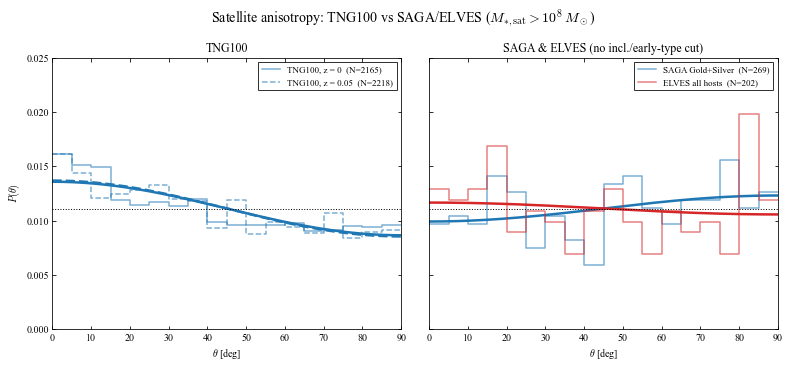

In [8]:
plot_tng_vs_obs("tng100", "TNG100")

## Figure 2 — TNG50 (z=0, z=0.05) vs SAGA/ELVES

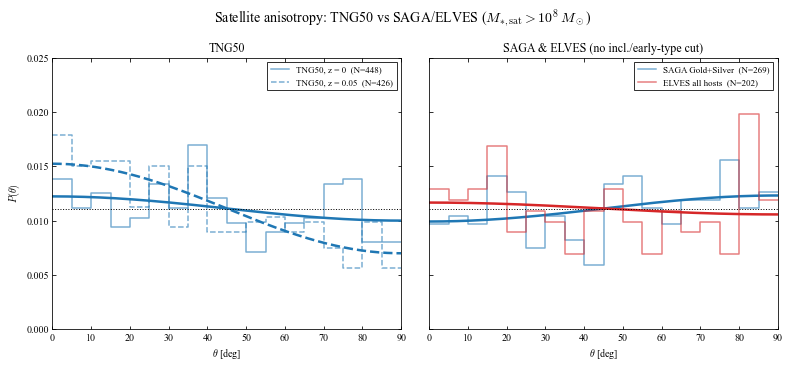

In [9]:
plot_tng_vs_obs("tng50", "TNG50")

## Quench fraction $f_q(\theta)=a+b\cos2\theta$

Now the **satellite quench fraction** vs angle, with the MCMC sinusoid fit (same model as
notebooks 03/06/07), for **TNG100 at z=0 and z=0.05** and **SAGA Gold+Silver + ELVES all hosts**.
The satellite quench proxies are: TNG `quenched` flag, SAGA `quenched` flag, and ELVES early-type
morphology (`ETG?`). Points + error bars = bootstrap $f_q$ per angle bin; line + band = posterior
median and 16-84th percentile; $b$ is the quench-anisotropy amplitude ($b=0$ is isotropic).

In [10]:
fq_data = {
    "TNG100, z=0":      (tng_alpha[("tng100", "z0")],    tng_quench[("tng100", "z0")]),
    "TNG100, z=0.05":   (tng_alpha[("tng100", "z0p05")], tng_quench[("tng100", "z0p05")]),
    "TNG50, z=0":       (tng_alpha[("tng50",  "z0")],    tng_quench[("tng50",  "z0")]),
    "TNG50, z=0.05":    (tng_alpha[("tng50",  "z0p05")], tng_quench[("tng50",  "z0p05")]),
    "SAGA Gold+Silver": (saga_gs["theta"].to_numpy(),    saga_gs["quenched"].to_numpy()),
    "ELVES all hosts":  (elves["theta"].to_numpy(),      elves["quenched"].to_numpy()),
}

fq_mean, fq_std, fq_p, fq_e = {}, {}, {}, {}
for label, (th, q) in fq_data.items():
    ok = np.isfinite(th) & np.isfinite(q)
    m, s = bootstrap_fq(th[ok], q[ok])
    fq_mean[label], fq_std[label] = m, s
    fq_p[label], fq_e[label] = fit_fq_sinusoid(m, s)

print(f"{'dataset':<20s}  {'a':>16s}   {'b':>16s}   |b|/sig_b")
for label in fq_data:
    p, e = fq_p[label], fq_e[label]
    print(f"{label:<20s}  {p[0]:.3f} +/- {e[0]:.3f}   {p[1]:+.3f} +/- {e[1]:.3f}   "
          f"{abs(p[1] / e[1]):.2f}")

dataset                              a                  b   |b|/sig_b
TNG100, z=0           0.367 +/- 0.011   -0.038 +/- 0.015   2.54
TNG100, z=0.05        0.342 +/- 0.012   -0.037 +/- 0.017   2.16
TNG50, z=0            0.377 +/- 0.024   -0.033 +/- 0.033   0.99
TNG50, z=0.05         0.389 +/- 0.025   -0.004 +/- 0.035   0.11
SAGA Gold+Silver      0.251 +/- 0.029   -0.037 +/- 0.041   0.91
ELVES all hosts       0.711 +/- 0.038   +0.057 +/- 0.051   1.12


### Quench-fraction figure

Left = the chosen TNG box at z=0 (circles, solid) and z=0.05 (squares, dashed); Right = SAGA
Gold+Silver (blue) and ELVES all hosts (red). Same two-panel layout as `plot_panels` in
notebook 06.

In [11]:
def plot_fq_panels(sim_name):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

    def _draw(ax, label, color, marker, ls):
        m, s = fq_mean[label], fq_std[label]
        p, e = fq_p[label], fq_e[label]
        sig = abs(p[1] / e[1]) if np.isfinite(p[1]) else np.nan
        ax.errorbar(ANGLE_CENTERS, m, yerr=s, fmt=marker, color=color, capsize=3, ms=5,
                    ls="none", label=f"{label}  (b={p[1]:+.3f}, |b|/$\\sigma$={sig:.1f})")
        if np.isfinite(p[1]):
            x, ymed, ylo, yhi = fq_band(p, e)
            ax.plot(x, ymed, color=color, ls=ls, lw=2)
            ax.fill_between(x, ylo, yhi, color=color, alpha=0.12)

    # ---- left: TNG box, both redshifts ----
    _draw(axL, f"{sim_name}, z=0",    TNG_C, "o", "-")
    _draw(axL, f"{sim_name}, z=0.05", TNG_C, "s", "--")
    axL.set_title(sim_name)

    # ---- right: SAGA Gold+Silver + ELVES ----
    _draw(axR, "SAGA Gold+Silver", SAGA_C,  "o", "-")
    _draw(axR, "ELVES all hosts",  ELVES_C, "s", "-")
    axR.set_title("SAGA & ELVES (no incl./early-type cut)")

    for ax in (axL, axR):
        ax.set_xlim(0, 90); ax.set_ylim(0, 1)
        ax.set_xlabel(r"$\theta$ [deg]")
        ax.legend(fontsize=9, fancybox=False, edgecolor="k")
        ax.tick_params(which="both", direction="in", top=True, right=True)
    axL.set_ylabel(r"$f_q$")
    fig.suptitle(rf"Quench fraction vs angle ($f_q = a + b\cos 2\theta$):  "
                 rf"{sim_name} vs SAGA/ELVES  ($M_{{*,\rm sat}} > 10^8\,M_\odot$)", y=1.02, fontsize=14)
    plt.subplots_adjust(wspace=0.08)
    plt.show()

### Figure 3 — quench fraction: TNG100 (z=0, z=0.05) vs SAGA/ELVES

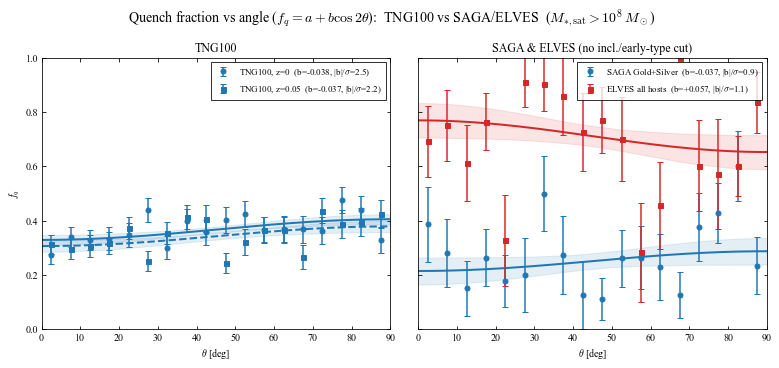

In [12]:
plot_fq_panels("TNG100")

### Figure 4 — quench fraction: TNG50 (z=0, z=0.05) vs SAGA/ELVES

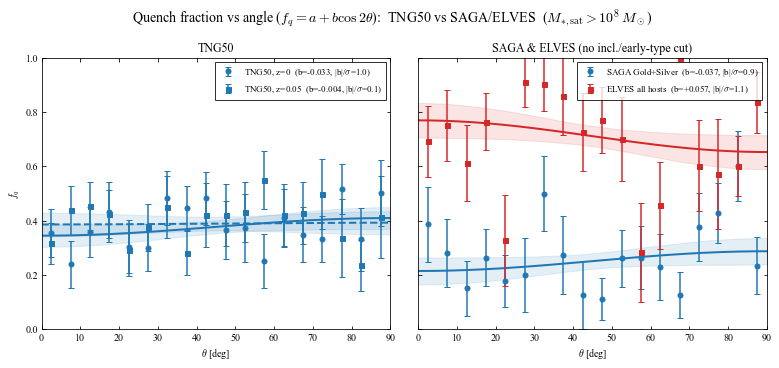

In [13]:
plot_fq_panels("TNG50")